<a href="https://colab.research.google.com/github/Kushen23/Statistical-Learning-e23290/blob/main/Kalman%20Filter%20Answers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Analytical Derivation

**1. A Priori State Distribution**
Starting with the linear process model $x^{-}_k = A_{k-1}x^{+}_{k-1} + G_{k-1}w_{k-1}$, I used the property that a linear combination of Gaussian random variables is also Gaussian.
*   **Mean:** Applying linearity of expectation, $\mathbb{E}[x^-_k] = A_{k-1}\mathbb{E}[x^+_{k-1}] + G_{k-1}\mathbb{E}[w_{k-1}]$. Since the process noise has a zero mean ($\mathbb{E}[w_{k-1}] = 0$), this simplifies to $m_k^- = A_{k-1}m_{k-1}$.
*   **Covariance:** Because the previous state $x^+_{k-1}$ and the process noise $w_{k-1}$ are independent, the variance is $Var(x^-_k) = A_{k-1}Var(x^+_{k-1})A_{k-1}^T + G_{k-1}Var(w_{k-1})G_{k-1}^T$. This gives us the priori covariance: $P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T$.

**2. Predictive Measurement Distribution**
For the measurement model $y^{-}_k = H_k x^{-}_k + z_k$:
*   **Mean:** $\mathbb{E}[y^-_k] = H_k\mathbb{E}[x^-_k] + \mathbb{E}[z_k]$. Since measurement noise has zero mean, this becomes $H_k m_k^-$.
*   **Covariance:** The variance is $Var(y^-_k) = H_k Var(x^-_k)H_k^T + Var(z_k)$, which expands to $H_k P_k^- H_k^T + \Sigma_m$.

**3. Joint Distribution**
Since the joint distribution of two Gaussian variables is also Gaussian, I just need to find the cross-covariance between $x_k^-$ and $y_k^-$ to construct the block matrix:
*   $Cov(x_k^-, y_k^-) = Cov(x_k^-, H_k x_k^- + z_k) = Var(x_k^-)H_k^T = P_k^- H_k^T$.
*   The symmetric block is $Cov(y_k^-, x_k^-) = H_k P_k^-$.
Combining these with the individual variances derived above yields the exact block matrix provided in the assignment description.

**4 & 5. A Posteriori State Distribution (Conditional)**
To find the updated state and answer both prompt 4 and 5, I applied the standard multivariate Gaussian conditioning formula for a joint distribution $\begin{bmatrix} X \\ Y \end{bmatrix} \sim \mathscr{N}\left(\begin{bmatrix} \mu_X \\ \mu_Y \end{bmatrix}, \begin{bmatrix} \Sigma_{XX} & \Sigma_{XY} \\ \Sigma_{YX} & \Sigma_{YY} \end{bmatrix}\right)$, where the conditional distribution $X|Y=y$ is defined as:
*   **Conditional Mean:** $\mu_{X|Y} = \mu_X + \Sigma_{XY}\Sigma_{YY}^{-1}(y - \mu_Y)$. Substituting my variables gives $m_k = m_k^- + P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1} (y^{\text{obs}}_k - H_k m_k^-)$.
*   **Conditional Covariance:** $\Sigma_{X|Y} = \Sigma_{XX} - \Sigma_{XY}\Sigma_{YY}^{-1}\Sigma_{YX}$. Substituting my variables gives $P_k = P_k^- - P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1} H_k P_k^-$.

By defining the Kalman Gain as $K_k \triangleq P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}$, these equations simplify down to the exact updated mean and covariance formulas required.

### 2. 1-D Example

For the scalar case, I adapted the matrix equations from the previous section by replacing them with the given scalar variables ($A=a$, $H=h$, $G=1$, $\Sigma_p=q$, $\Sigma_m=r$).

**1. State Prediction**
*   $m_k^- = \mathbb{E}[a x^+_{k-1} + w_{k-1}] = a m_{k-1}$.
*   $P_k^- = Var(a x^+_{k-1} + w_{k-1}) = a^2 P_{k-1} + q$.

**2. State Update**
Letting the innovation variance be $S_k = h^2 P_k^- + r$, the scalar Kalman gain becomes $K_k = P_k^- h / S_k$.
*   $m_k = m_k^- + K_k(y^{\text{obs}}_k - h m_k^-)$.
*   $P_k = P_k^- - K_k h P_k^- = (1 - K_k h)P_k^- = (1 - \frac{P_k^- h^2}{S_k})P_k^-$.

**3. Predictive Measurement Distribution**
Before observing $y_k$, the predicted measurement is $y^-_k = h x^-_k + z_k$.
*   Mean: $h m_k^-$.
*   Variance: $h^2 P_k^- + r$.
Thus, $p(y^-_k | Y_{k-1}) = \mathscr{N}(h m_k^-, h^2 P_k^- + r)$.

**4. Posterior-Predictive Measurement Distribution**
After filtering on $y_k$, the updated state estimate is $x^+_k \sim \mathscr{N}(m_k, P_k)$. The new predictive measurement relies on this updated state.
*   Mean: $h m_k$.
*   Variance: $h^2 P_k + r$.
Thus, $p(y^-_k \mid Y_k) = \mathscr{N}(h m_k, h^2 P_k + r)$.

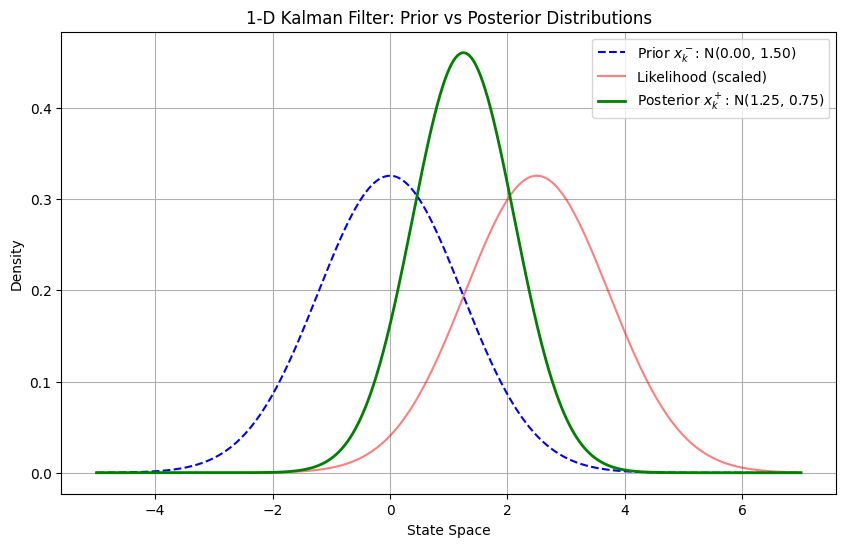

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Part 5: 1-D Example Numerical Simulation
# Defining arbitrary but sensible parameters for the simulation
a, q, h, r = 1.0, 0.5, 1.0, 1.5
m_prev, P_prev = 0.0, 1.0 # Prior at step k-1
y_obs = 2.5 # Simulated observation at time k

# Step 1: Predict phase
m_prior = a * m_prev
P_prior = (a**2) * P_prev + q

# Step 2: Update phase (Filtering)
S = (h**2) * P_prior + r
K = (P_prior * h) / S
m_post = m_prior + K * (y_obs - h * m_prior)
P_post = (1 - K * h) * P_prior

# Generating PDFs for visualization
x_axis = np.linspace(-5, 7, 1000)
pdf_prior = norm.pdf(x_axis, m_prior, np.sqrt(P_prior))
pdf_post = norm.pdf(x_axis, m_post, np.sqrt(P_post))
pdf_likelihood = norm.pdf(y_obs, h * x_axis, np.sqrt(r))

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(x_axis, pdf_prior, label=f'Prior $x_k^-$: N({m_prior:.2f}, {P_prior:.2f})', color='blue', linestyle='--')
plt.plot(x_axis, pdf_likelihood, label='Likelihood (scaled)', color='red', alpha=0.5)
plt.plot(x_axis, pdf_post, label=f'Posterior $x_k^+$: N({m_post:.2f}, {P_post:.2f})', color='green', linewidth=2)

plt.title('1-D Kalman Filter: Prior vs Posterior Distributions')
plt.xlabel('State Space')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

### 3. 2D-Position Estimation

**Part A**

The state vector is defined as $x_k = [p_x(k), p_y(k), v_x(k), v_y(k)]^T$.

To find the required matrices, I applied basic kinematic equations for constant velocity motion over a time step $\Delta t$. The position and velocity updates are:
*   $p_x(k) = p_x(k-1) + v_x(k-1)\Delta t + \frac{1}{2}a_x\Delta t^2$
*   $p_y(k) = p_y(k-1) + v_y(k-1)\Delta t + \frac{1}{2}a_y\Delta t^2$
*   $v_x(k) = v_x(k-1) + a_x\Delta t$
*   $v_y(k) = v_y(k-1) + a_y\Delta t$

Here, the acceleration $(a_x, a_y)$ represents my random process noise vector $w_{k-1}$.

**Deriving Matrix A:**
By ignoring the noise term momentarily, the mapping from $x_{k-1}$ to $x_k$ looks like this:
$$
\begin{bmatrix} p_x(k) \\ p_y(k) \\ v_x(k) \\ v_y(k) \end{bmatrix} = \begin{bmatrix} 1 & 0 & \Delta t & 0 \\ 0 & 1 & 0 & \Delta t \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix} \begin{bmatrix} p_x(k-1) \\ p_y(k-1) \\ v_x(k-1) \\ v_y(k-1) \end{bmatrix}
$$
This directly gives me the state transition matrix $A$.

**Deriving Matrix G:**
To find $G$, I isolated the process noise (acceleration) terms mapping to the state:
$$
G w_{k-1} = \begin{bmatrix} \frac{1}{2}\Delta t^2 & 0 \\ 0 & \frac{1}{2}\Delta t^2 \\ \Delta t & 0 \\ 0 & \Delta t \end{bmatrix} \begin{bmatrix} a_x \\ a_y \end{bmatrix}
$$
This matches the matrix $G$ structure specified in the problem.

**Deriving Matrix H:**
Since the measurement $y_k$ only observes the position components $(p_x, p_y)$, the matrix $H$ must extract only the first two components of the 4D state vector:
$$
\begin{bmatrix} p_x^{\text{meas}}(k) \\ p_y^{\text{meas}}(k) \end{bmatrix} = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{bmatrix} \begin{bmatrix} p_x(k) \\ p_y(k) \\ v_x(k) \\ v_y(k) \end{bmatrix}
$$

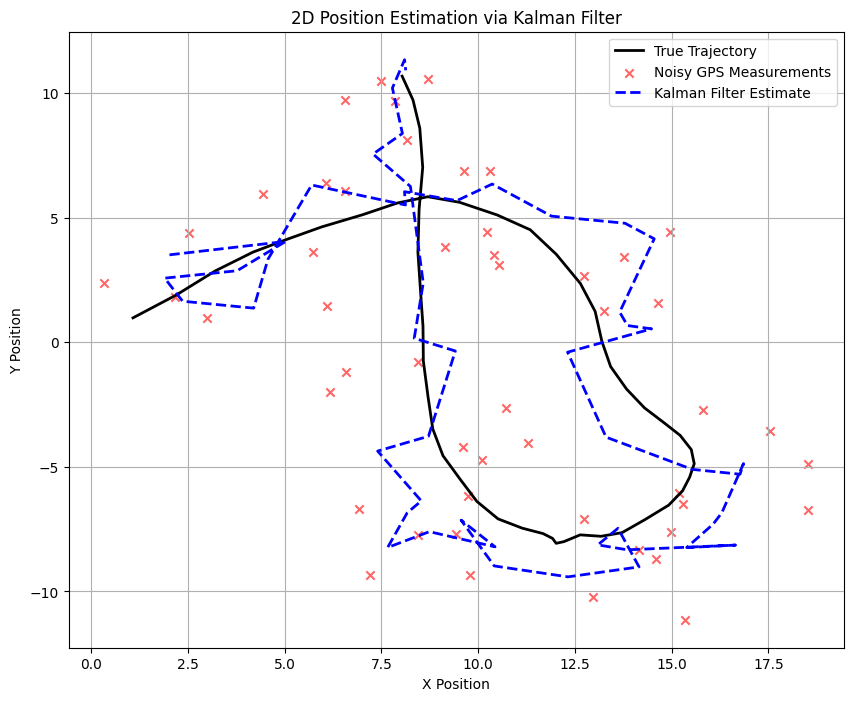

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Part B: My Python implementation to filter noisy GPS measurements
np.random.seed(42) # For reproducible results

# --- Setting up parameters ---
dt = 1.0 # Time step
num_steps = 50
sigma_p = 0.1 # Process noise variance (acceleration uncertainty)
sigma_m = 5.0 # Measurement noise variance (GPS inaccuracy)

# Defining the system matrices based on my derivations in Part A
A = np.array([[1, 0, dt, 0],
              [0, 1, 0, dt],
              [0, 0, 1, 0],
              [0, 0, 0, 1]])

G = np.array([[0.5 * dt**2, 0],
              [0, 0.5 * dt**2],
              [dt, 0],
              [0, dt]])

H = np.array([[1, 0, 0, 0],
              [0, 1, 0, 0]])

# Setting up covariance matrices
Q = G @ (np.eye(2) * sigma_p) @ G.T # Process noise covariance mapped to state space
R = np.eye(2) * sigma_m # Measurement noise covariance

# --- Generating Synthetic Data for testing ---
true_states = []
measurements = []
x_true = np.array([0, 0, 1, 1]) # Starting state: x=0, y=0, vx=1, vy=1

for _ in range(num_steps):
    # Simulating the true state evolution with process noise
    w = np.random.multivariate_normal([0, 0], np.eye(2) * sigma_p)
    x_true = A @ x_true + G @ w
    true_states.append(x_true)

    # Simulating the noisy GPS measurement
    z = np.random.multivariate_normal([0, 0], R)
    y = H @ x_true + z
    measurements.append(y)

true_states = np.array(true_states)
measurements = np.array(measurements)

# --- My Kalman Filter Implementation ---
x_est = np.array([0, 0, 0, 0]) # Initial state guess
P_est = np.eye(4) * 10 # Initial high uncertainty
filtered_states = []

for y_obs in measurements:
    # 1. Prediction Step
    x_pred = A @ x_est
    P_pred = A @ P_est @ A.T + Q

    # 2. Update Step
    S = H @ P_pred @ H.T + R
    K = P_pred @ H.T @ np.linalg.inv(S)

    x_est = x_pred + K @ (y_obs - H @ x_pred)
    P_est = (np.eye(4) - K @ H) @ P_pred

    filtered_states.append(x_est)

filtered_states = np.array(filtered_states)

# --- Plotting the Results ---
plt.figure(figsize=(10, 8))
plt.plot(true_states[:, 0], true_states[:, 1], label='True Trajectory', color='black', linewidth=2)
plt.scatter(measurements[:, 0], measurements[:, 1], label='Noisy GPS Measurements', color='red', marker='x', alpha=0.6)
plt.plot(filtered_states[:, 0], filtered_states[:, 1], label='Kalman Filter Estimate', color='blue', linewidth=2, linestyle='--')

plt.title('2D Position Estimation via Kalman Filter')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.legend()
plt.grid(True)
plt.show()